In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import (StandardScaler, LabelEncoder)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

In [2]:
df = pd.read_csv('titanic_cleaned.csv')
df.head()

,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [3]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'siblings_spouses',
       'parents_children', 'fare', 'embarked', 'class', 'who', 'adult_male',
       'embark_town', 'alive', 'alone'],
      dtype='object')

In [4]:
drop_cols = ['class', 'who', 'adult_male','embark_town', 'alive', 'alone']
df.drop(columns=drop_cols, axis=1, inplace=True)

In [5]:
df.head()

,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775 entries, 0 to 774
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   survived          775 non-null    int64  
 1   pclass            775 non-null    int64  
 2   sex               775 non-null    object 
 3   age               775 non-null    float64
 4   siblings_spouses  775 non-null    int64  
 5   parents_children  775 non-null    int64  
 6   fare              775 non-null    float64
 7   embarked          775 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 48.6+ KB


In [7]:
df.describe()

,survived,pclass,age,siblings_spouses,parents_children,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100 
print(pd.concat([missing, missing_pct], axis=1, keys=['Count', 'Percent%']))

                  Count  Percent%
survived              0       0.0
pclass                0       0.0
sex                   0       0.0
age                   0       0.0
siblings_spouses      0       0.0
parents_children      0       0.0
fare                  0       0.0
embarked              0       0.0


In [9]:
df.dtypes

survived              int64
pclass                int64
sex                  object
age                 float64
siblings_spouses      int64
parents_children      int64
fare                float64
embarked             object
dtype: object

In [10]:
# categorical columns 
cat_col = df.select_dtypes(include='object').columns.to_list()
for col in cat_col: 
    print(f" {col} : {df[col].unique()}")


 sex : ['male' 'female']
 embarked : ['S' 'C' 'Q']


In [11]:
df.head()

,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
df.dtypes

survived              int64
pclass                int64
sex                  object
age                 float64
siblings_spouses      int64
parents_children      int64
fare                float64
embarked             object
dtype: object

In [13]:
# Encode 'sex'
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])
print(dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

{'female': np.int64(0), 'male': np.int64(1)}


In [14]:
bool_col = df.select_dtypes(include='bool').columns
df[bool_col] = df[bool_col].astype(int)

df.head()

,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,0,1
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,0,1
3,1,1,0,35.0,1,0,53.1000,0,1
4,0,3,1,35.0,0,0,8.0500,0,1


In [15]:
X = df.drop(columns=['survived'], axis = 1)
y = df['survived']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, 
    test_size=0.2, 
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (620, 8)
Test size: (155, 8)


In [19]:
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled).round(2)

print("First 5 Predictions")
print(y_pred[:5])

print()
print("First 5 preddiction probabilities")
print(y_pred_prob[:5])

First 5 Predictions
[0 0 0 1 1]

First 5 preddiction probabilities
[[0.91 0.09]
 [0.6  0.4 ]
 [0.9  0.1 ]
 [0.13 0.87]
 [0.43 0.57]]


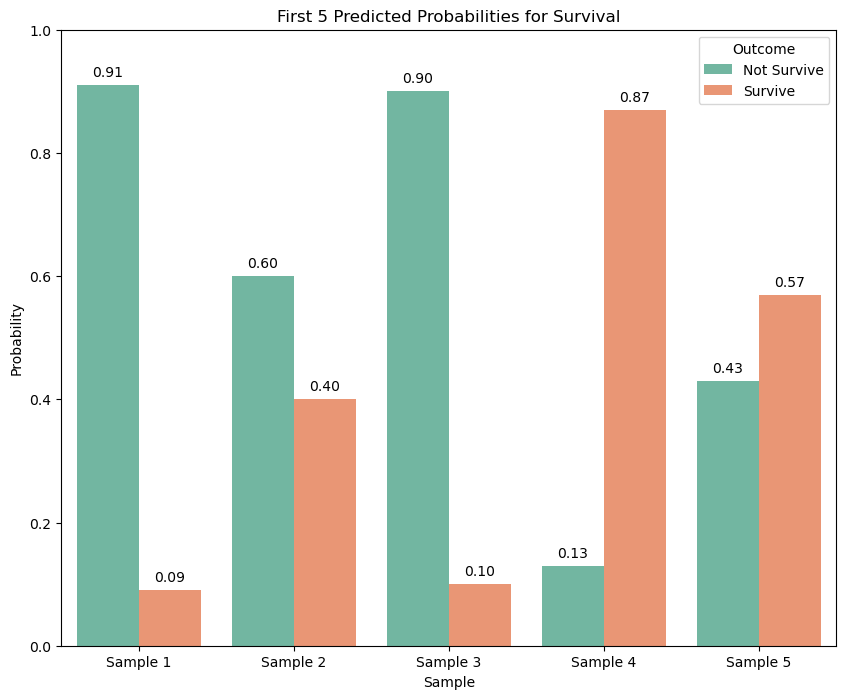

In [20]:
prob_pred_not_survive = y_pred_prob[:5,0]
prob_pred_survive = y_pred_prob[:5,1]

data = {
    "Sample": [f"Sample {i+1}" for i in range(len(prob_pred_survive))],
    "Not Survive": prob_pred_not_survive,
    "Survive": prob_pred_survive
}
df_probs = pd.DataFrame(data)

# Melt into long format for seaborn
df_melted = df_probs.melt(id_vars="Sample", 
                          value_vars=["Not Survive", "Survive"], 
                          var_name="Outcome", 
                          value_name="Probability")

# Plot
plt.figure(figsize=(10,8))
ax = sns.barplot(x="Sample", y="Probability", hue="Outcome",palette='Set2', data=df_melted)
for container in ax.containers: 
    ax.bar_label(container, fmt='%.2f', padding=4)

plt.title("First 5 Predicted Probabilities for Survival")
plt.ylim(0,1)
plt.show()

Accuracy: 76.77%

          Predicted 0  Predicted 1
Actual 0           77           18
Actual 1           18           42



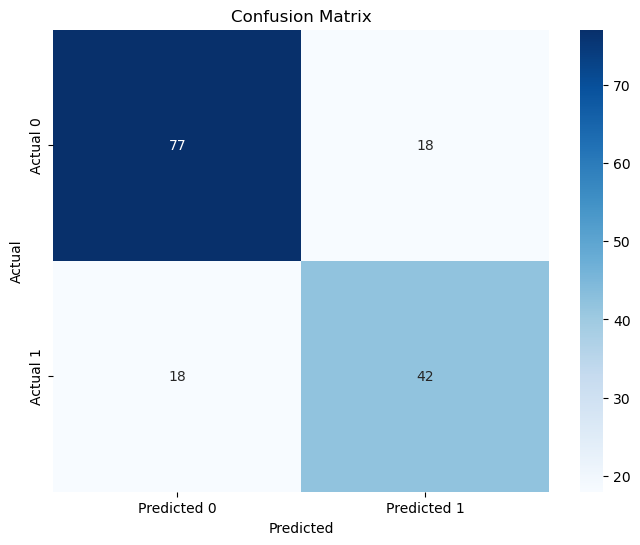

In [21]:
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print()  

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm, 
                     index=["Actual 0", "Actual 1"], 
                     columns=["Predicted 0", "Predicted 1"])

print(cm_df)
print()


plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        95
           1       0.70      0.70      0.70        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155



In [23]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(
    importance.sort_values(
        by="Coefficient",
        ascending=False
    )
)

            Feature  Coefficient
5              fare     0.067060
4  parents_children    -0.048104
6        embarked_Q    -0.145782
7        embarked_S    -0.205048
3  siblings_spouses    -0.403844
2               age    -0.552714
0            pclass    -0.916807
1               sex    -1.119629


In [24]:
print(X.columns.tolist())

['pclass', 'sex', 'age', 'siblings_spouses', 'parents_children', 'fare', 'embarked_Q', 'embarked_S']


In [27]:
# Test with new input
import numpy as np

# New passenger data
# [pclass, sex, age, siblings_spouses, parents_children, fare, embarked_Q, embarked_S]
# sex: female=0, male=1
# embarked: C=base (both 0), Q=(1,0), S=(0,1)

new_passenger = pd.DataFrame({
    'pclass'           : [1],
    'sex'              : [0],   # female
    'age'              : [29],
    'siblings_spouses' : [0],
    'parents_children' : [0],
    'fare'             : [100],
    'embarked_Q'       : [0],
    'embarked_S'       : [0],   # Cherbourg
})
new_scaled = scaler.transform(new_passenger)

# Predict
prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

print(f"Survived: {'Yes ✅' if prediction[0] == 1 else 'No ❌'}")
print(f"Survival Probability : {probability[0][1]*100:.1f}%")
print(f"Death Probability    : {probability[0][0]*100:.1f}%")

Survived: Yes ✅
Survival Probability : 95.6%
Death Probability    : 4.4%


In [28]:
# predicting 10 sample data 

test_passengers = pd.DataFrame({
    'pclass'           : [1, 3, 2, 1, 3, 2, 1, 3, 2, 3],
    'sex'              : [0, 1, 0, 1, 0, 1, 0, 1, 1, 0],   # 0=female, 1=male
    'age'              : [29, 22, 15, 45, 8,  35, 60, 30, 25, 18],
    'siblings_spouses' : [0,  1,  1,  0,  3,  0,  1,  0,  0,  0],
    'parents_children' : [0,  0,  1,  0,  1,  0,  0,  0,  0,  0],
    'fare'             : [100, 7.25, 21, 80, 15, 13, 120, 8, 10, 12],
    'embarked_Q'       : [0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
    'embarked_S'       : [0,  1,  1,  1,  1,  0,  0,  0,  1,  1],
})

labels = [
    "1st class female, age 29",
    "3rd class male, age 22",
    "2nd class female, age 15",
    "1st class male, age 45",
    "3rd class female, age 8 (child)",
    "2nd class male, age 35",
    "1st class female, age 60",
    "3rd class male, age 30",
    "2nd class male, age 25",
    "3rd class female, age 18",
]

# Scale
test_scaled = scaler.transform(test_passengers)

# Predict
predictions  = model.predict(test_scaled)
probabilities = model.predict_proba(test_scaled)

# Display
print("=" * 55)
for i in range(len(labels)):
    survived = predictions[i]
    prob_yes  = probabilities[i][1] * 100
    prob_no   = probabilities[i][0] * 100

    print(f"\nPassenger {i+1}: {labels[i]}")
    print(f"  Survived            : {'Yes ✅' if survived == 1 else 'No ❌'}")
    print(f"  Survival Probability: {prob_yes:.1f}%")
    print(f"  Death Probability   : {prob_no:.1f}%")
    print("-" * 55)


Passenger 1: 1st class female, age 29
  Survived            : Yes ✅
  Survival Probability: 95.6%
  Death Probability   : 4.4%
-------------------------------------------------------

Passenger 2: 3rd class male, age 22
  Survived            : No ❌
  Survival Probability: 11.0%
  Death Probability   : 89.0%
-------------------------------------------------------

Passenger 3: 2nd class female, age 15
  Survived            : Yes ✅
  Survival Probability: 82.3%
  Death Probability   : 17.7%
-------------------------------------------------------

Passenger 4: 1st class male, age 45
  Survived            : No ❌
  Survival Probability: 41.3%
  Death Probability   : 58.7%
-------------------------------------------------------

Passenger 5: 3rd class female, age 8 (child)
  Survived            : No ❌
  Survival Probability: 48.3%
  Death Probability   : 51.7%
-------------------------------------------------------

Passenger 6: 2nd class male, age 35
  Survived            : No ❌
  Survival